In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extracting Data

In [59]:
DIR = "./data/"
FILENAME = "dataset_churn_risk.csv"

df = pd.read_csv(DIR+FILENAME)

df.head()

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1


In [60]:
print("Column Names: ", list(df.columns))
print("Data Shape: ", df.shape)
print("---------------Data types---------------------------------------------------")
print(df.dtypes)


Column Names:  ['tenure_months', 'monthly_charges', 'support_tickets', 'avg_session_minutes', 'late_payments', 'contract_months', 'target']
Data Shape:  (1000, 7)
---------------Data types---------------------------------------------------
tenure_months            int64
monthly_charges        float64
support_tickets          int64
avg_session_minutes    float64
late_payments            int64
contract_months          int64
target                   int64
dtype: object


# 2. EDA

## 2.1 Missing Data

In [61]:
df.isnull().sum().sort_values(ascending=False)

tenure_months          0
monthly_charges        0
support_tickets        0
avg_session_minutes    0
late_payments          0
contract_months        0
target                 0
dtype: int64

## 2.2 Target Variable

In [62]:
# verify possible class imbalance for the target
df["target"].value_counts(normalize=True)

target
0    0.5
1    0.5
Name: proportion, dtype: float64

In [63]:
# verify the existence of outliers
print(df["target"].describe())

count    1000.00000
mean        0.50000
std         0.50025
min         0.00000
25%         0.00000
50%         0.50000
75%         1.00000
max         1.00000
Name: target, dtype: float64


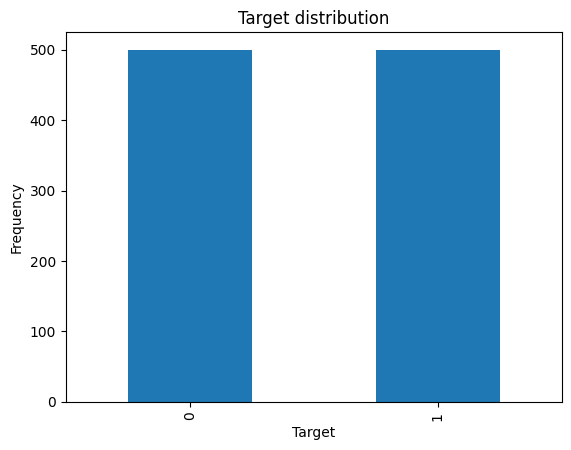

In [64]:
# plot the target distribution per class
plt.figure()
df["target"].value_counts().plot(kind="bar", title="Target distribution")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()
plt.close()

## 2.3 Visualizing Data

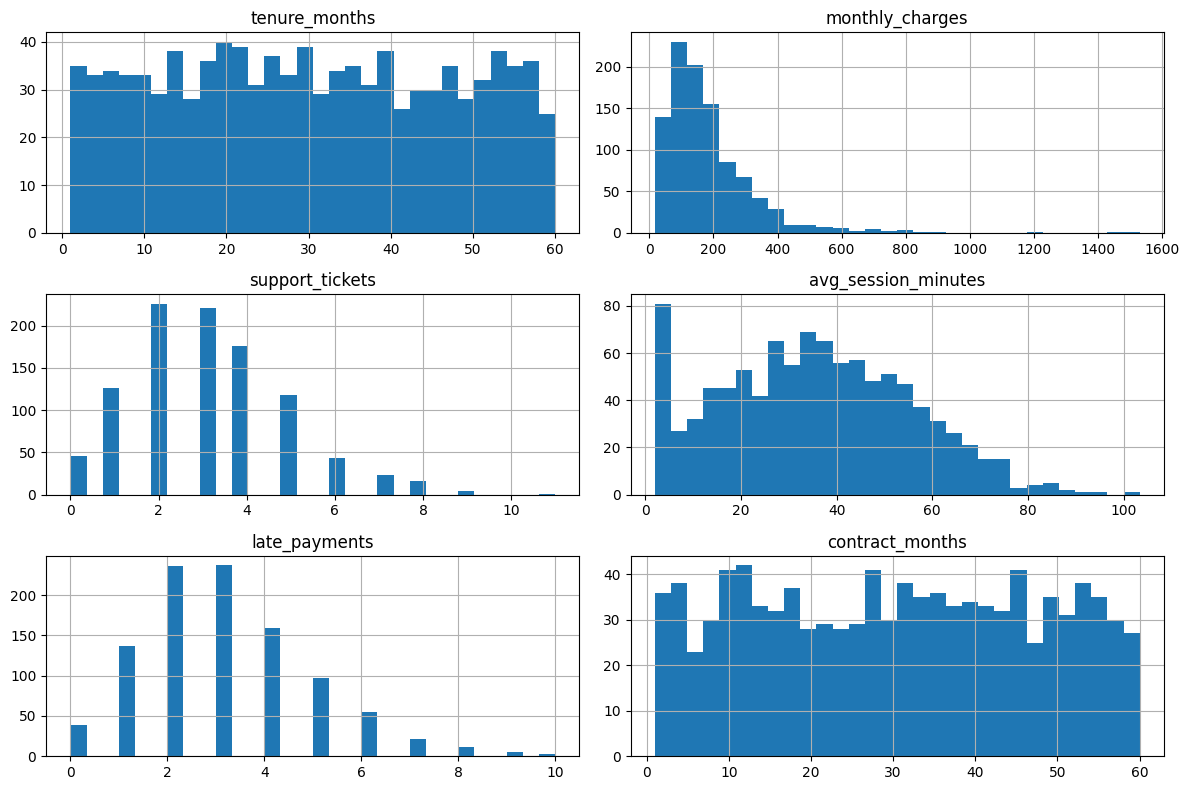

In [65]:
# small number of features - lets display the overall distributions
df.drop(columns=["target"]).hist(figsize=(12, 8), bins=30)
plt.tight_layout()

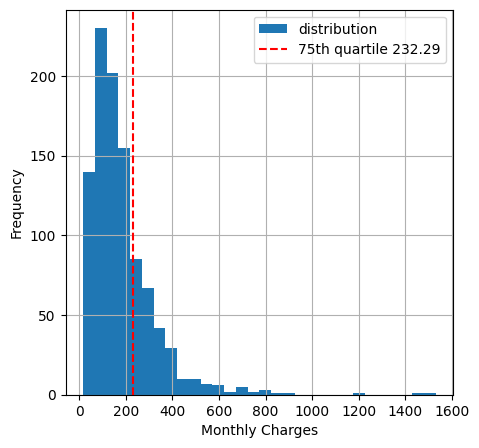

In [66]:
# possible outliers on monthly charges

quantile_70 = list(df["monthly_charges"].quantile([0.75]))
plt.figure(figsize=(5, 5))
df["monthly_charges"].hist(bins=30, label = 'distribution')
plt.axvline(quantile_70, linestyle = '--', color = 'red', label = f'75th quartile {quantile_70[0]:.2f}')
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## A high number of events over the 75th percentile. It is risky to drop this tailed values



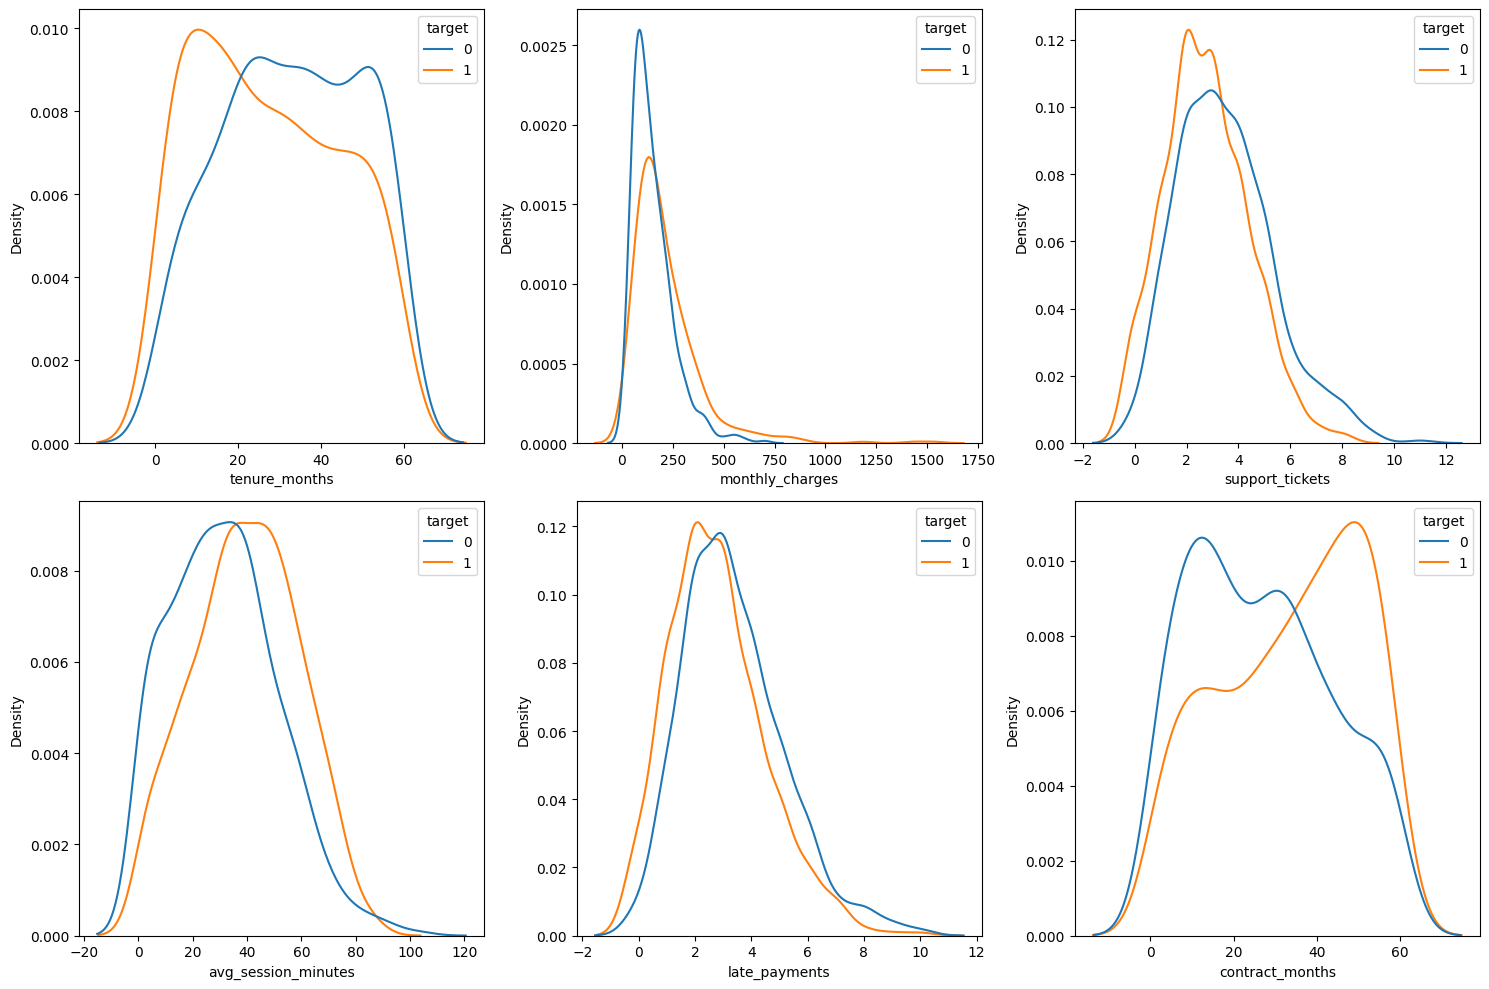

In [67]:
# lets plot the distributions by categorical target

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ["tenure_months", "monthly_charges", "support_tickets", "avg_session_minutes", "late_payments", "contract_months"]

for feat, ax in zip(features, axes.flat):
    sns.kdeplot(data=df, x=feat, hue = "target", ax = ax)
plt.tight_layout()
plt.show()
plt.close()

In [68]:
# mean of each feature by target class, to quantify what the KDEs show visually
df.groupby("target")[features].mean()

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months
target,,,,,,
0,32.858,151.23758,3.496,31.34468,3.378,26.760
1,27.384,214.23896,2.762,39.67822,2.784,33.708


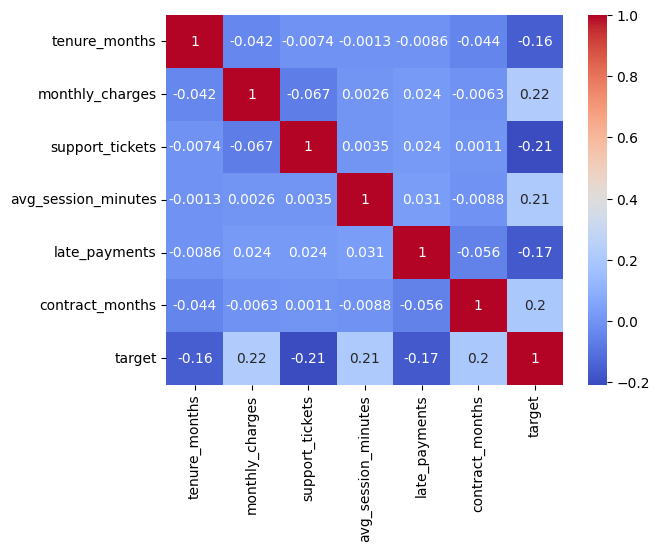

In [69]:
# Now lets analyze correlations with target
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()
plt.close()


**Conclusions from Data Visualizations:**
- `monthly_charges` is heavily right-skewed with a long outlier tail — risky to drop those rows outright.
- `avg_session_minutes` shows two overlapping subpopulations (near-zero usage vs. broader engaged group).
- All features are weakly correlated with `target` (`|r|` 0.16–0.21) and overlap heavily between classes — no single strong predictor.
- Features are nearly uncorrelated with each other — no multicollinearity concern.

## 2.4 Data Cleaning

In [70]:
# duplicates
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [71]:
# invalid values: impossible negatives/zeros and out-of-range values
numeric_features = ["tenure_months", "monthly_charges", "support_tickets", "avg_session_minutes", "late_payments", "contract_months"]

print("Negative values per column:")
print((df[numeric_features] < 0).sum())

print("\nNon-positive monthly_charges (a paying customer should have charges > 0):", (df["monthly_charges"] <= 0).sum())

print("\nUnexpected target values (should only be 0/1):", df.loc[~df["target"].isin([0, 1])].shape[0])

print("\navg_session_minutes above a plausible daily cap (>1440 min):", (df["avg_session_minutes"] > 1440).sum())

Negative values per column:
tenure_months          0
monthly_charges        0
support_tickets        0
avg_session_minutes    0
late_payments          0
contract_months        0
dtype: int64

Non-positive monthly_charges (a paying customer should have charges > 0): 0

Unexpected target values (should only be 0/1): 0

avg_session_minutes above a plausible daily cap (>1440 min): 0


**Everything OK with Data Cleaning**

## 2.5 Feature Engineering

In [72]:
# friction_score: support_tickets + late_payments combined into a single signal.

df["friction_score"] = df["support_tickets"] + df["late_payments"]

## 2.6 Feature Selection

In [73]:
df.corr(numeric_only=True)["target"].sort_values(ascending=False)

target                 1.000000
monthly_charges        0.217740
avg_session_minutes    0.208914
contract_months        0.201443
tenure_months         -0.159055
late_payments         -0.168456
support_tickets       -0.207164
friction_score        -0.262553
Name: target, dtype: float64

**friction_score could be a good feature**

# 3. Preprocessing Data

In [74]:
from sklearn.model_selection import train_test_split

# separate input and target variables
X = df.drop(columns=["target"])
y = df["target"]

# splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# split into train and test
X_train = X_train.copy()
X_test = X_test.copy()

## 3.1 Feature Scaling

In [75]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include="number").columns
scaler = StandardScaler()
# trainnig data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# test data
X_test[num_cols] = scaler.transform(X_test[num_cols])

## 3.2 Encoding Categorical Variables

In [76]:
cat_cols = X_train.select_dtypes(include="object").columns
print(list(cat_cols))
#just for practice. No categorical features are presented
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

[]


# 4. Training

In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
# record the exact hyperparameters used to fit this model 
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [79]:
# coefficients are on the standardized feature scale
coefficients = pd.Series(model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
odds_ratios = np.exp(coefficients)

pd.DataFrame({"coefficient": coefficients, "odds_ratio": odds_ratios})

,coefficient,odds_ratio
monthly_charges,0.646984,1.909772
contract_months,0.536170,1.709446
avg_session_minutes,0.508296,1.662455
tenure_months,-0.351475,0.703649
friction_score,-0.310654,0.732967
support_tickets,-0.233831,0.791496
late_payments,-0.213959,0.807381


**Coefficient interpretation:**
- `monthly_charges` has the largest positive coefficient — the single strongest driver of predicted churn, consistent with 2.3.
- `contract_months` (×1.71) and `avg_session_minutes` (×1.66) also push toward churn.
- `tenure_months` (×0.70), `friction_score` (×0.73), `support_tickets` (×0.79) and `late_payments` (×0.81) all push toward retention — again with `support_tickets`/`late_payments` inverted from real-world intuition.
- `friction_score` is a linear combination of `support_tickets` and `late_payments` by construction, so these three coefficients are fit on collinear inputs — their individual magnitudes are less trustworthy than their shared direction. This is also why adding `friction_score` didn't move the model's overall accuracy/ROC-AUC (2.5): the model could already reconstruct that sum from its two components.

# 5. Model Evaluation

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.68      0.69      0.68       100
           1       0.68      0.67      0.68       100

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.68      0.68       200

ROC-AUC: 0.7494


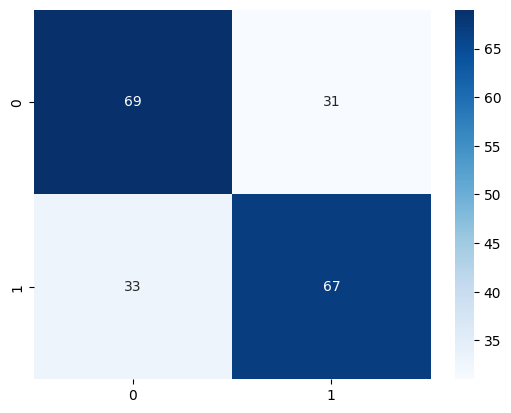

In [81]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.show()

In [82]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Positives  (churners correctly caught):        {tp} / {tp + fn} actual churners")
print(f"False Negatives (churners the model missed):        {fn} / {tp + fn} actual churners")
print(f"True Negatives  (non-churners correctly retained):  {tn} / {tn + fp} actual non-churners")
print(f"False Positives (non-churners wrongly flagged):     {fp} / {tn + fp} actual non-churners")

True Positives  (churners correctly caught):        67 / 100 actual churners
False Negatives (churners the model missed):        33 / 100 actual churners
True Negatives  (non-churners correctly retained):  69 / 100 actual non-churners
False Positives (non-churners wrongly flagged):     31 / 100 actual non-churners


**Confusion matrix interpretation:** of the 100 actual churners in the test set, the model catches 67 and misses 33 — those 33 false negatives are lost-revenue cases that wouldn't get flagged for a retention action. Of the 100 actual non-churners, 31 are wrongly flagged as at-risk (false positives) — each would trigger an unnecessary retention offer. As discussed earlier, in most subscription businesses a missed churner is more costly than a wasted retention offer, so the 33 false negatives are the more concerning error type here; lowering the classification threshold below 0.5 would trade some of them for more false positives, but only worth doing with real cost numbers behind it.

## Train vs Test Performance

In [83]:
# a large train-test gap would signal overfitting; both scores being
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)
train_proba = model.predict_proba(X_train)[:, 1]

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy: ", accuracy_score(y_test, y_pred))
print("Train ROC-AUC: ", roc_auc_score(y_train, train_proba))
print("Test ROC-AUC:  ", roc_auc_score(y_test, y_proba))

Train accuracy: 0.7025
Test accuracy:  0.68
Train ROC-AUC:  0.7741
Test ROC-AUC:   0.7494


## Learning Curve

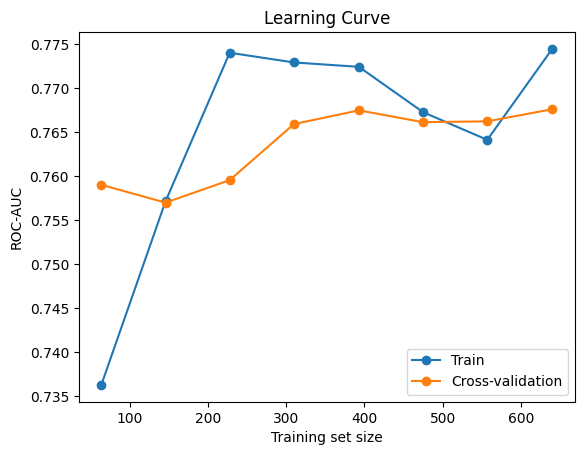

In [84]:
# train vs cross-validation score as training set size grows.

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000), X_train, y_train,
    cv=5, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42,
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation")
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.legend()
plt.show()

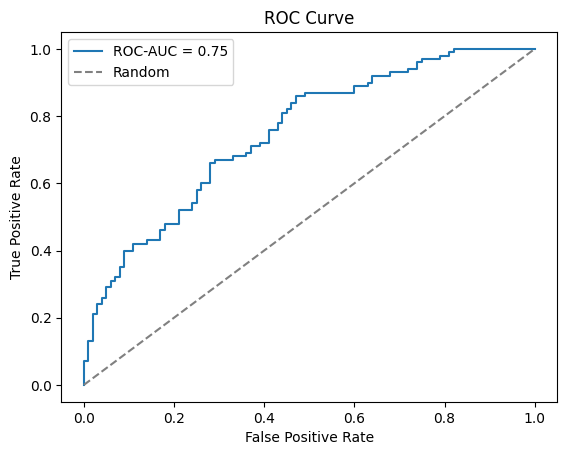

In [85]:
# ROC curve: the shape behind the ROC-AUC scalar already computed above
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Conclusions from Model Evaluation:**
- Logistic regression reaches ~68% accuracy / 0.75 ROC-AUC — clearly above random guessing (~50%), but far from strong separation.
- Train and test scores are close (no overfitting); the learning curve plateaus early — the model is underfitting, limited by weak feature signal rather than model capacity.
- Further gains are more likely to come from better/more features than from more data or hyperparameter tuning.

## Limitations & Improvements

**Limitations:**
- Logistic Regression is a linear model — it cannot capture feature interactions or non-linear effects, and the learning curve already shows the model is underfitting (bias-limited), not data-starved.
- `friction_score` is a linear combination of `support_tickets` and `late_payments`, so those three coefficients are estimated on collinear inputs — their individual magnitudes should be read with caution.
- No hyperparameter tuning was performed; `C`, `penalty`, and `solver` are all left at sklearn defaults.

**Possible improvements:**
- Try a model that can capture non-linear structure to test whether the ~0.75 ROC-AUC ceiling is a data-quality limit or a model-capacity one.
- Use k-fold cross-validation to quantify uncertainty around the reported metrics instead of relying on one split.
- If deployed against real data, revisit the classification threshold using actual business costs (customer lifetime value vs. retention-offer cost) rather than the default 0.5.
- Validate the pipeline against real historical churn data before trusting any of these directional conclusions operationally.